In [ ]:
import os
import torch
import torchaudio
import torch
import torchaudio.functional as F
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd
import numpy as np
import warnings
import kagglehub
import seaborn as sns
import torchaudio.transforms as T
warnings.filterwarnings('ignore')

# Download latest version
path = kagglehub.dataset_download("adarshsingh0903/audio-deepfake-detection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'audio-deepfake-detection-dataset' dataset.
Path to dataset files: /kaggle/input/audio-deepfake-detection-dataset


In [ ]:
# List the contents of the downloaded path
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")

audio-deepfake-detection-dataset/
    VoiceBox/
    OpenAI/
    VALLE/
    NaturalSpeech3/
    xTTS/
    PromptTTS2/
    FlashSpeech/
    seedtts_files/
    real_samples/


In [ ]:
def get_audio_specs(path):
    """Safely extracts audio specs without crashing if info() is missing."""
    try:
        # We load just a header-level amount of data to get the specs
        waveform, sr = torchaudio.load(path)
        return {
            "Sample_Rate": sr,
            "Channels": waveform.shape[0],
            "Duration_Sec": waveform.shape[1] / sr,
            "Dtype": waveform.dtype,
            "Status": "OK"
        }
    except Exception as e:
        return {"Status": f"Error: {str(e)}"}

In [ ]:
def scan_dataset_with_torch(path):
    all_stats = []

    # Iterate through your Kaggle folders
    for folder in os.listdir(path):
        folder_path = os.path.join(path, folder)
        if not os.path.isdir(folder_path): continue

        label = 'Real' if 'real' in folder.lower() else 'Fake'
        files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.wav', '.mp3'))]

        print(f"Analyzing {folder}...")

        for f in files:
            f_path = os.path.join(folder_path, f)
            f_size = os.path.getsize(f_path)

            # 1. Detect Missing Values (Empty Files)
            if f_size == 0:
                all_stats.append({'Generator': folder, 'Label': label, 'Status': 'Missing/0KB'})
                continue

            # 2. Extract Types (First 5 per folder to save time)
            # You can remove the 'if' to scan every single file if needed
            meta = get_audio_specs(f_path)
            all_stats.append({
                'Generator': folder,
                'Label': label,
                'Size_KB': f_size / 1024,
                **meta
            })

    return pd.DataFrame(all_stats)

# Run the scan
df_stat = scan_dataset_with_torch(path)

Analyzing VoiceBox...
Analyzing OpenAI...
Analyzing VALLE...
Analyzing NaturalSpeech3...
Analyzing xTTS...
Analyzing PromptTTS2...
Analyzing FlashSpeech...
Analyzing seedtts_files...
Analyzing real_samples...


In [ ]:
df_stat

,Generator,Label,Size_KB,Sample_Rate,Channels,Duration_Sec,Dtype,Status
0,VoiceBox,Fake,342.230469,16000,1,10.95,torch.float32,OK
1,VoiceBox,Fake,207.542969,16000,1,6.64,torch.float32,OK
2,VoiceBox,Fake,174.730469,16000,1,5.59,torch.float32,OK
3,VoiceBox,Fake,423.480469,16000,1,13.55,torch.float32,OK
4,VoiceBox,Fake,508.792969,16000,1,16.28,torch.float32,OK
...,...,...,...,...,...,...,...,...
4442,real_samples,Real,1246.917969,24000,1,26.60,torch.float32,OK
4443,real_samples,Real,202.074219,24000,1,4.31,torch.float32,OK
4444,real_samples,Real,246.136719,24000,1,5.25,torch.float32,OK
4445,real_samples,Real,644.105469,24000,1,13.74,torch.float32,OK


In [ ]:
def present_data_report(df_stat):
    # --- IS IT BALANCED? ---
    print("\n" + "="*30 + "\n1. DATA BALANCE\n" + "="*30)
    balance = df_stat.groupby(['Generator', 'Label']).size().reset_index(name='Count')
    print(balance)

    counts = df_stat['Label'].value_counts()
    print(f"\nOverall: {counts.to_dict()}")
    print("Conclusion: The dataset is Slightly Imbalanced")

    # --- MISSING VALUES? ---
    print("\n" + "="*30 + "\n2. INTEGRITY CHECK\n" + "="*30)
    missing = len(df_stat[df_stat['Status'] != 'OK'])
    print(f"Missing/Corrupted samples: {missing}")

    # --- TYPES OF FEATURES? ---
    print("\n" + "="*30 + "\n3. FEATURE TYPES\n" + "="*30)
    # This shows the exact Tensor specs your model will use
    types = df_stat[df_stat['Status'] == 'OK'].groupby('Label').agg({
        'Sample_Rate': 'unique',
        'Dtype': 'unique',
        'Channels': 'unique',
        'Duration_Sec': ['mean', 'min', 'max']
    })
    types.columns = ['_'.join(col).strip() for col in types.columns.values]
    print(types)

present_data_report(df_stat)


1. DATA BALANCE
        Generator Label  Count
0     FlashSpeech  Fake    118
1  NaturalSpeech3  Fake     32
2          OpenAI  Fake    600
3      PromptTTS2  Fake     25
4           VALLE  Fake     95
5        VoiceBox  Fake    104
6    real_samples  Real   2274
7   seedtts_files  Fake    599
8            xTTS  Fake    600

Overall: {'Real': 2274, 'Fake': 2173}
Conclusion: The dataset is Slightly Imbalanced

2. INTEGRITY CHECK
Missing/Corrupted samples: 0

3. FEATURE TYPES
          Sample_Rate_unique     Dtype_unique Channels_unique  \
Label                                                           
Fake   [16000, 24000, 22050]  [torch.float32]             [1]   
Real                 [24000]  [torch.float32]             [1]   

       Duration_Sec_mean  Duration_Sec_min  Duration_Sec_max  
Label                                                         
Fake            5.402511          1.266667             26.33  
Real            8.623564          3.000000             36.72  


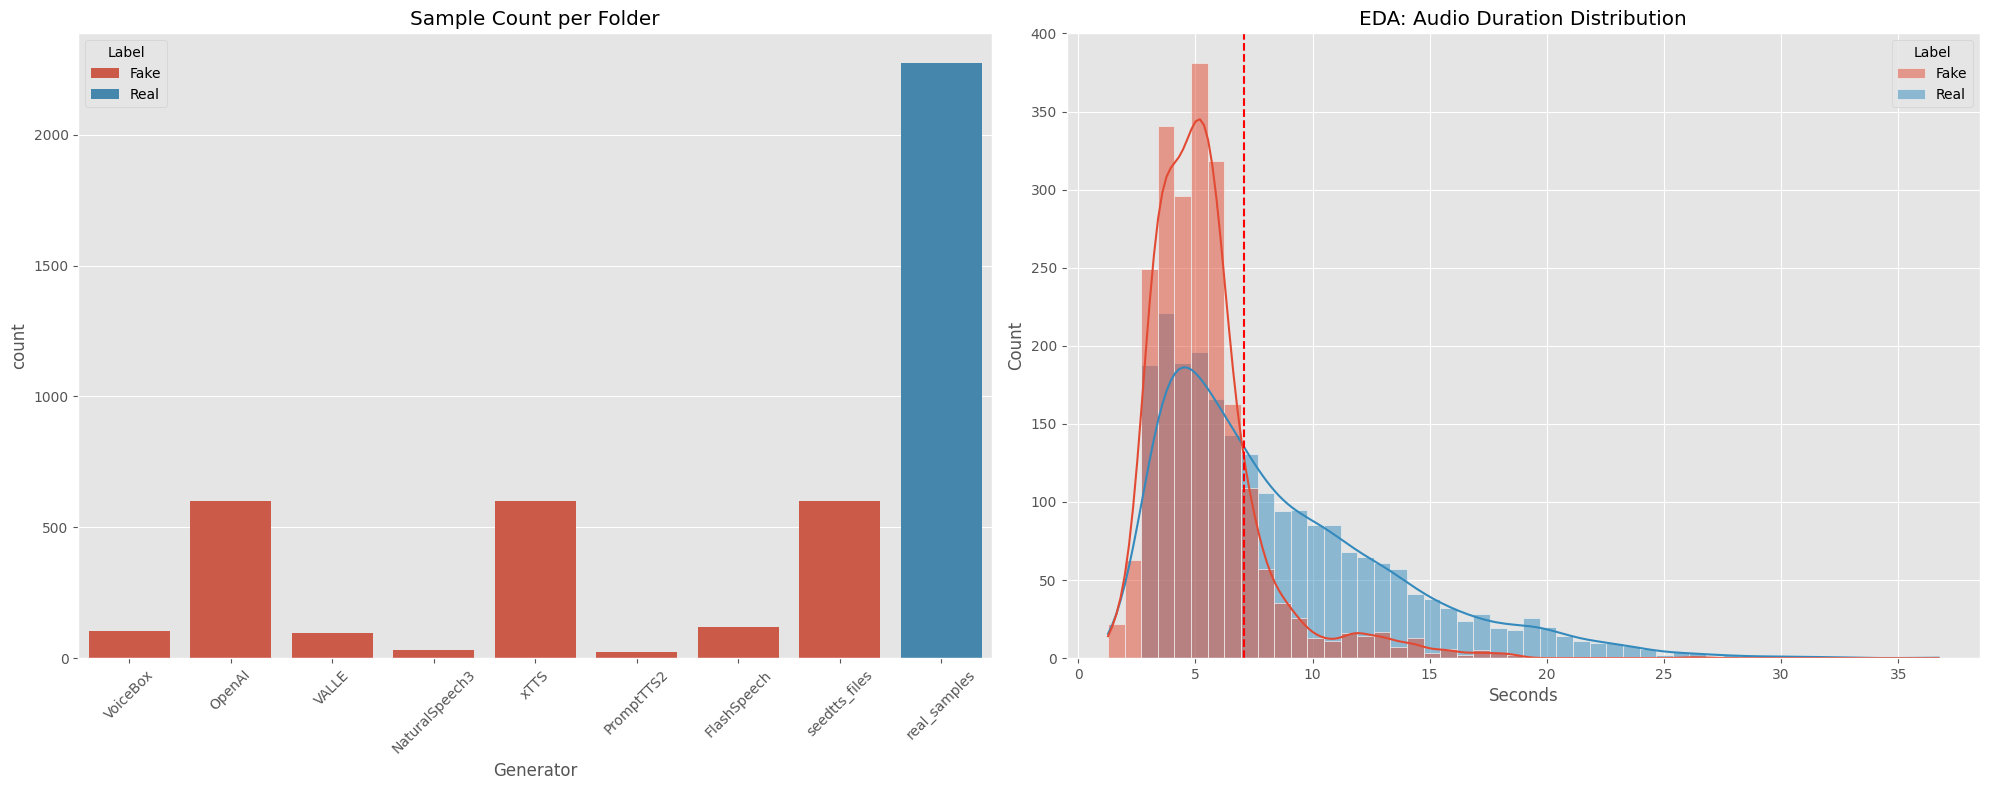

In [ ]:
def plot_presentation_visuals(df_stat):
    plt.style.use('ggplot')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # Visual 1: Generator Distribution
    sns.countplot(data=df_stat, x='Generator', hue='Label', ax=ax1)
    ax1.set_title("Sample Count per Folder")
    ax1.tick_params(axis='x', rotation=45)

    # Visual 2: Duration Distribution
    sns.histplot(data=df_stat, x='Duration_Sec', hue='Label', bins=50, kde=True, ax=ax2)
    plt.axvline(df_stat['Duration_Sec'].mean(), color='red', linestyle='--', label='Mean')
    plt.title("EDA: Audio Duration Distribution")
    plt.xlabel("Seconds")


    plt.tight_layout()
    plt.show()

plot_presentation_visuals(df_stat)

In [ ]:
# Re-mapping the physical paths into a clear DataFrame
data_list = []
for folder in os.listdir(path):
    folder_path = os.path.join(path, folder)
    if os.path.isdir(folder_path):
        label = 'Real' if 'real' in folder.lower() else 'Fake'
        for f in os.listdir(folder_path):
            if f.endswith(('.wav', '.mp3')):
                data_list.append({
                    'file_path': os.path.join(folder_path, f), # This fixes the KeyError
                    'Generator': folder,
                    'Label': label
                })

df = pd.DataFrame(data_list)
print(f"DataFrame Ready. Columns: {df.columns.tolist()}")

DataFrame Ready. Columns: ['file_path', 'Generator', 'Label']


In [ ]:
df

,file_path,Generator,Label
0,/kaggle/input/audio-deepfake-detection-dataset...,VoiceBox,Fake
1,/kaggle/input/audio-deepfake-detection-dataset...,VoiceBox,Fake
2,/kaggle/input/audio-deepfake-detection-dataset...,VoiceBox,Fake
3,/kaggle/input/audio-deepfake-detection-dataset...,VoiceBox,Fake
4,/kaggle/input/audio-deepfake-detection-dataset...,VoiceBox,Fake
...,...,...,...
4442,/kaggle/input/audio-deepfake-detection-dataset...,real_samples,Real
4443,/kaggle/input/audio-deepfake-detection-dataset...,real_samples,Real
4444,/kaggle/input/audio-deepfake-detection-dataset...,real_samples,Real
4445,/kaggle/input/audio-deepfake-detection-dataset...,real_samples,Real


Text(0.5, 1.0, 'Forensic EDA: Frequency Center of Gravity (Real vs Fake)')

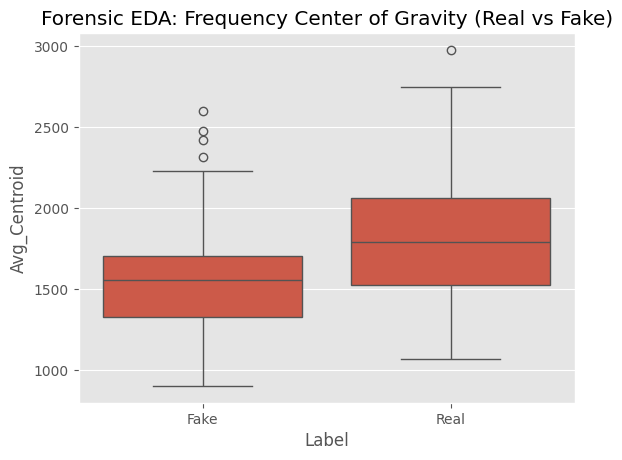

In [34]:
def get_spectral_centroid_stats(df, n_samples=100):
    subset = df.groupby('Label').sample(n_samples)
    results = []

    # Transform to find the "center of gravity" of frequencies
    centroid_transform = T.SpectralCentroid(sample_rate=16000)

    for _, row in subset.iterrows():
        waveform, sr = torchaudio.load(row['file_path'])
        # Standardize for the EDA
        if sr != 16000: waveform = T.Resample(sr, 16000)(waveform)

        centroid = centroid_transform(waveform)
        results.append({
            'Label': row['Label'],
            'Avg_Centroid': torch.mean(centroid).item()
        })
    return pd.DataFrame(results)

# Run and Plot
centroid_df = get_spectral_centroid_stats(df)
sns.boxplot(data=centroid_df, x='Label', y='Avg_Centroid')
plt.title("Forensic EDA: Frequency Center of Gravity (Real vs Fake)")

Processing FlashSpeech...
Processing NaturalSpeech3...
Processing OpenAI...
Processing PromptTTS2...
Processing VALLE...
Processing VoiceBox...
Processing real_samples...
Processing seedtts_files...
Processing xTTS...


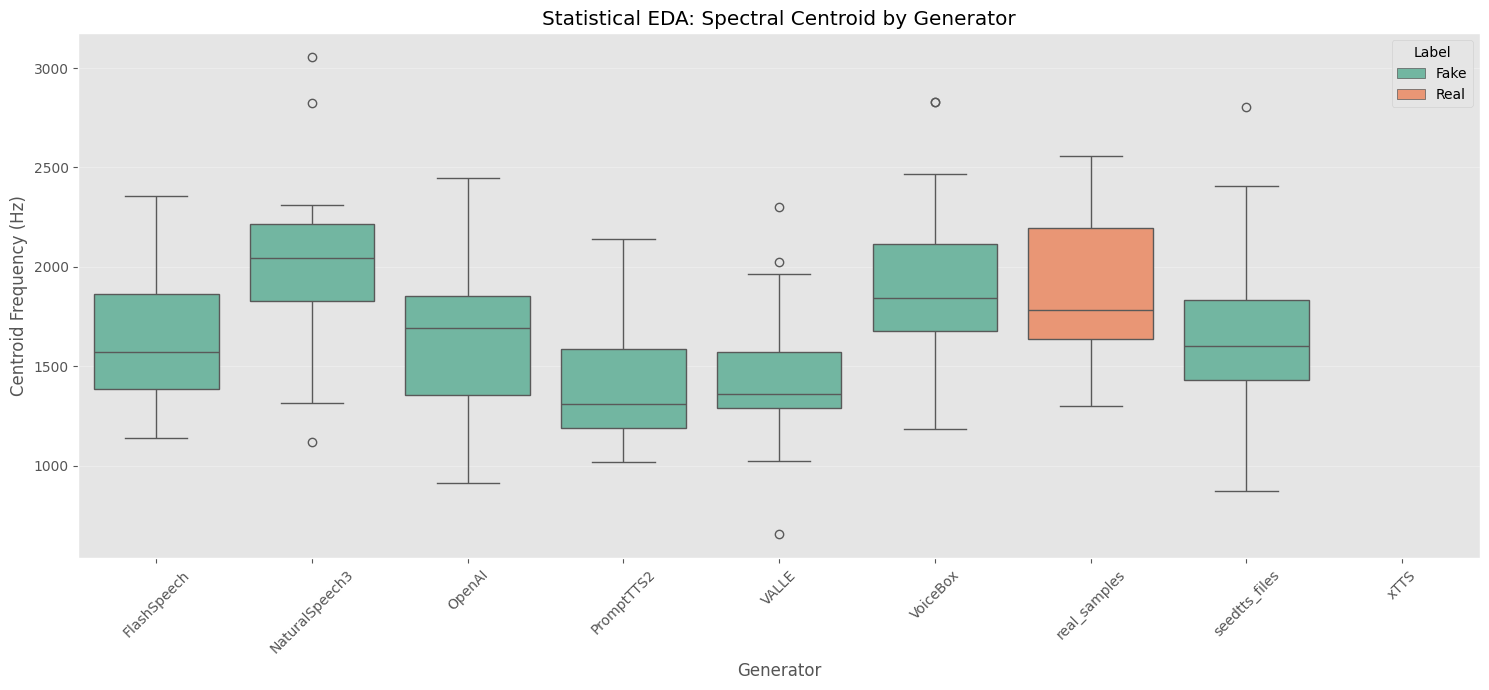

In [ ]:
def get_generator_stats(df, samples_per_gen=30):
    all_results = []

    # Initialize the same transform you used before
    centroid_transform = T.SpectralCentroid(sample_rate=16000, n_fft=1024)

    # Group by Generator to ensure we see every 'brand' of AI
    for generator, group in df.groupby('Generator'):
        print(f"Processing {generator}...")

        # Take a random sample to keep the code fast but accurate
        sample_size = min(len(group), samples_per_gen)
        subset = group.sample(sample_size)

        for path in subset['file_path']:
            try:
                waveform, sr = torchaudio.load(path)

                # Apply your standard 'Fairness' logic (Mono + Resample + Normalize)
                if waveform.shape[0] > 1: waveform = waveform.mean(0, keepdim=True)
                if sr != 16000: waveform = T.Resample(sr, 16000)(waveform)
                waveform = waveform / (waveform.abs().max() + 1e-8)

                # Get the average 'brightness' for this specific file
                c = centroid_transform(waveform)
                avg_val = c.mean().item()

                all_results.append({
                    'Generator': generator,
                    'Label': group['Label'].iloc[0],
                    'Avg_Centroid': avg_val
                })
            except Exception:
                continue

    return pd.DataFrame(all_results)

# --- Execute and Plot ---
# This will take a minute depending on your CPU/Disk speed
stats_df = get_generator_stats(df)

plt.figure(figsize=(15, 7))
sns.boxplot(data=stats_df, x='Generator', y='Avg_Centroid', hue='Label', palette='Set2')
plt.xticks(rotation=45)
plt.title("Statistical EDA: Spectral Centroid by Generator")
plt.ylabel("Centroid Frequency (Hz)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

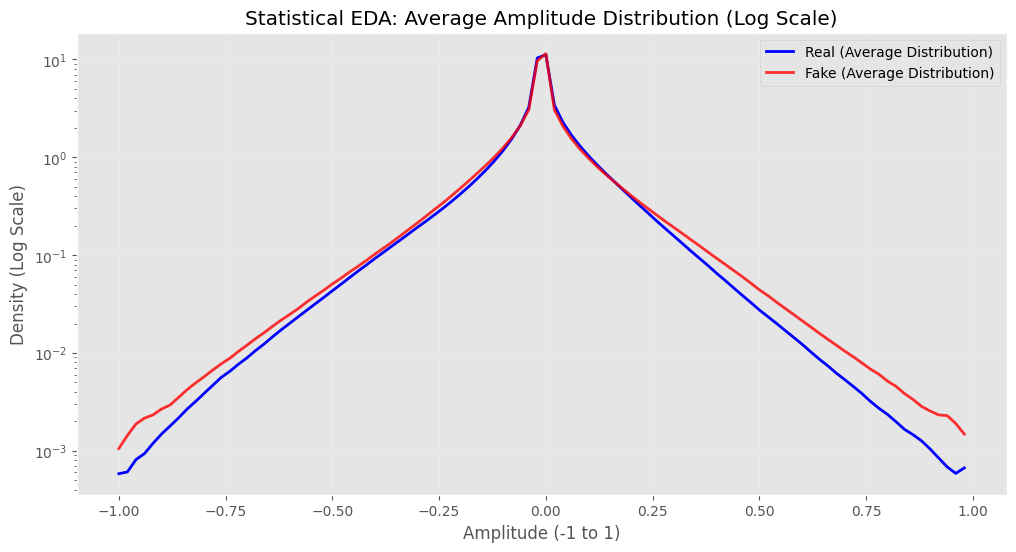

In [32]:
def get_avg_amplitude_dist(df, label_name, num_samples=100):
    subset = df[df['Label'] == label_name].sample(n=min(num_samples, len(df)))
    all_histograms = []

    # We define a fixed range for the bins to ensure they align perfectly
    bins = np.linspace(-1, 1, 101)

    for path in subset['file_path']:
        try:
            waveform, _ = torchaudio.load(path)
            # Normalize to 1.0 peak
            waveform = waveform / (waveform.abs().max() + 1e-8)

            # Calculate the histogram for THIS file
            counts, _ = np.histogram(waveform.numpy().flatten(), bins=bins, density=True)
            all_histograms.append(counts)
        except:
            continue

    # Return the average of all histograms
    return np.mean(all_histograms, axis=0), bins

# --- Execution ---
plt.figure(figsize=(12, 6))

# Get averaged data
real_mean, bins = get_avg_amplitude_dist(df, "Real")
fake_mean, _ = get_avg_amplitude_dist(df, "Fake")

# Plotting the "Average" signatures
plt.plot(bins[:-1], real_mean, label="Real (Average Distribution)", color='blue', lw=2)
plt.plot(bins[:-1], fake_mean, label="Fake (Average Distribution)", color='red', lw=2, alpha=0.8)

# Use Log Scale to see the 'Noise Floor' (the tiny details near zero)
plt.yscale('log')
plt.title("Statistical EDA: Average Amplitude Distribution (Log Scale)")
plt.xlabel("Amplitude (-1 to 1)")
plt.ylabel("Density (Log Scale)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

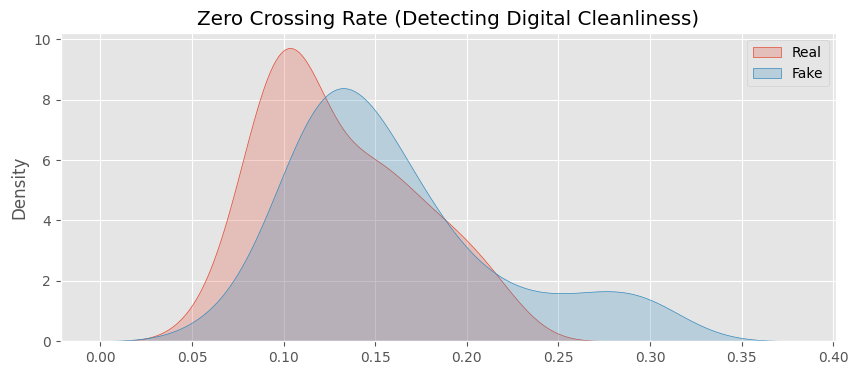

In [ ]:
def plot_zcr_comparison(file_paths, label):
    # Compute Zero Crossing Rate using PyTorch
    # We look at how many times the signal crosses the zero-axis
    zcrs = []
    for p in file_paths[:100]:
        wave, _ = torchaudio.load(p)
        # Sign change detection
        zcr = torch.mean((torch.sign(wave[:, 1:]) != torch.sign(wave[:, :-1])).float())
        zcrs.append(zcr.item())

    sns.kdeplot(zcrs, label=label, fill=True)

plt.figure(figsize=(10, 4))
plot_zcr_comparison(df[df['Label'] == 'Real']['file_path'].tolist(), "Real")
plot_zcr_comparison(df[df['Label'] == 'Fake']['file_path'].tolist(), "Fake")
plt.title("Zero Crossing Rate (Detecting Digital Cleanliness)")
plt.legend()
plt.show()

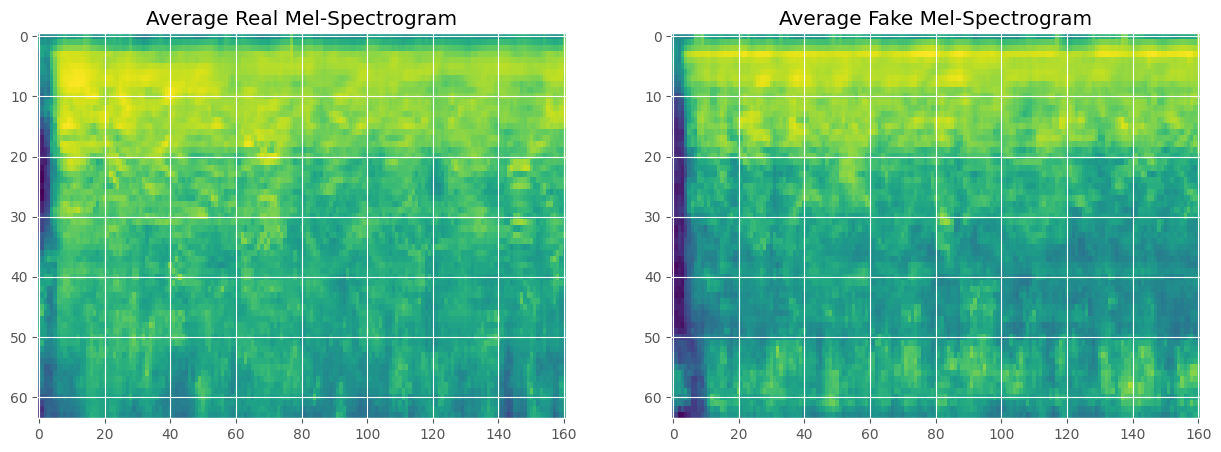

In [33]:
def get_average_spec(file_paths, n_samples=100):
    specs = []
    transform = torchaudio.transforms.MelSpectrogram(sample_rate=16000, n_mels=64)

    for p in file_paths[:n_samples]:
        wave, sr = torchaudio.load(p)
        if sr != 16000: wave = torchaudio.transforms.Resample(sr, 16000)(wave)
        # Fix length to 2 seconds for averaging
        wave = wave[:, :32000] if wave.shape[1] > 32000 else torch.nn.functional.pad(wave, (0, 32000-wave.shape[1]))
        specs.append(transform(wave))

    return torch.mean(torch.stack(specs), dim=0)

real_avg = get_average_spec(df[df['Label'] == 'Real']['file_path'].tolist())
fake_avg = get_average_spec(df[df['Label'] == 'Fake']['file_path'].tolist())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.imshow(torchaudio.transforms.AmplitudeToDB()(real_avg).squeeze().numpy(), aspect='auto')
ax1.set_title("Average Real Mel-Spectrogram")
ax2.imshow(torchaudio.transforms.AmplitudeToDB()(fake_avg).squeeze().numpy(), aspect='auto')
ax2.set_title("Average Fake Mel-Spectrogram")
plt.show()

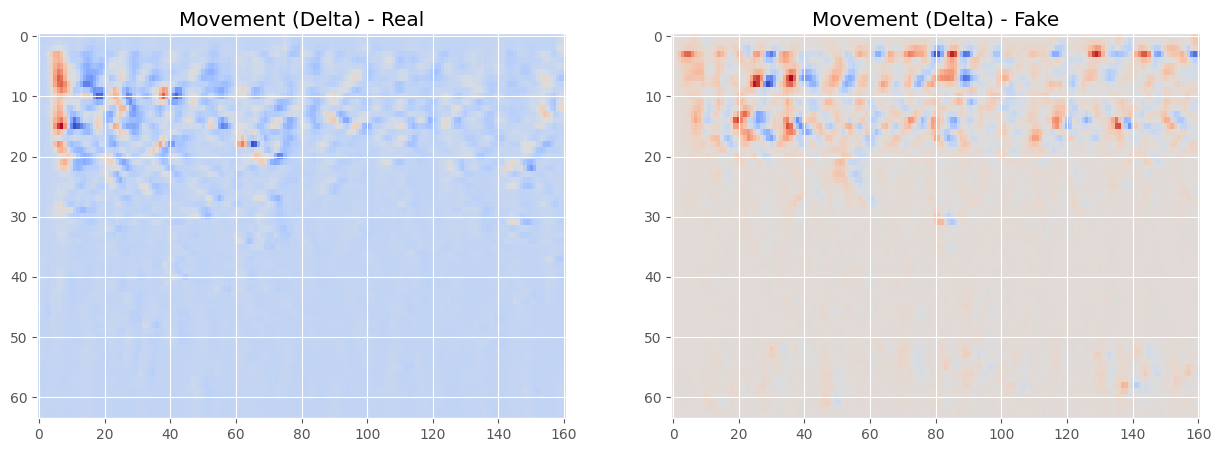

In [ ]:
# Add this to your existing plotting logic to see the 'movement' of the sound
def get_delta_spec(spec_tensor):
    # This calculates the difference between adjacent frames
    # It shows how the audio 'changes'
    delta = torchaudio.functional.compute_deltas(spec_tensor)
    return delta

real_delta = get_delta_spec(real_avg)
fake_delta = get_delta_spec(fake_avg)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.imshow(real_delta.squeeze().numpy(), aspect='auto', cmap='coolwarm')
ax1.set_title("Movement (Delta) - Real")
ax2.imshow(fake_delta.squeeze().numpy(), aspect='auto', cmap='coolwarm')
ax2.set_title("Movement (Delta) - Fake")
plt.show()

In [ ]:
def extract_features_for_tsne(df, n_samples=1000):
    # Sample equally from Real and Fake
    subset = df.groupby('Label').sample(n_samples // 2)
    features = []

    # Define a standard MFCC transform
    mfcc_transform = torchaudio.transforms.MFCC(
        sample_rate=16000,
        n_mfcc=13,
        melkwargs={'n_fft': 400, 'hop_length': 160, 'n_mels': 23, 'center': False}
    )

    for path in subset['file_path']:
        waveform, sr = torchaudio.load(path)
        # Resample to 16k (Fixes the inconsistency found in your stats)
        if sr != 16000:
            waveform = torchaudio.transforms.Resample(sr, 16000)(waveform)

        # Get MFCCs and take the mean over time
        mfcc = mfcc_transform(waveform)
        features.append(torch.mean(mfcc, dim=-1).flatten().numpy())

    return np.array(features), subset['Label'], subset['Generator']

# Run extraction
X, y_labels, y_generators = extract_features_for_tsne(df)

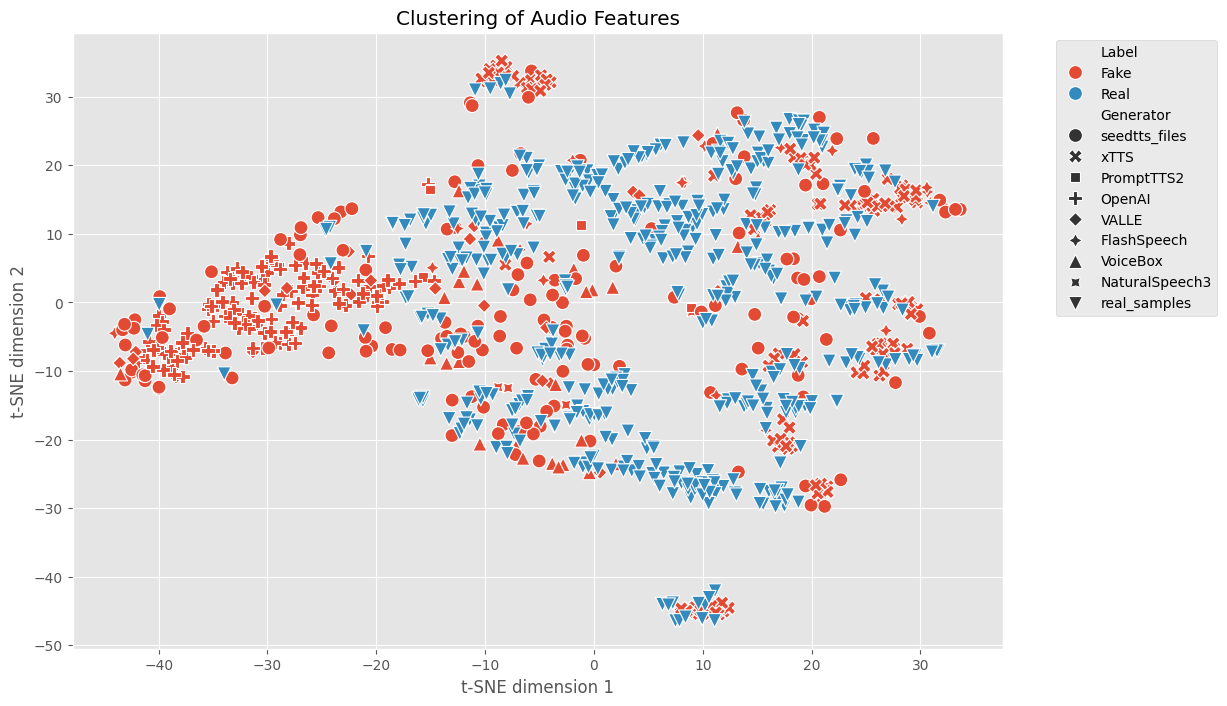

In [ ]:
# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_embedded = tsne.fit_transform(X)

# Plotting
plt.figure(figsize=(12, 8))
# Color by Label (Real vs Fake)
sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=y_labels, style=y_generators, s=100)
plt.title("Clustering of Audio Features")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [35]:
import torch
import torchaudio
import torchaudio.transforms as T
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def get_rolloff_stats(df, n_samples=100, roll_percent=0.85):
    subset = df.groupby('Label').sample(n=min(n_samples, len(df)//2))
    results = []

    for _, row in subset.iterrows():
        try:
            waveform, sr = torchaudio.load(row['file_path'])

            # 1. Standardize to 16kHz so the 'ceiling' is the same for all
            if sr != 16000:
                waveform = T.Resample(sr, 16000)(waveform)

            # 2. Compute Spectrogram (Magnitude)
            spec = T.Spectrogram(n_fft=1024)(waveform).abs()

            # 3. Calculate Cumulative Energy across frequencies
            # We sum energy from bottom to top
            total_energy = torch.sum(spec, dim=1)
            cumulative_energy = torch.cumsum(spec, dim=1)

            # 4. Find the frequency bin where we hit 85% of total energy
            threshold = roll_percent * total_energy
            # Find the first index where cumulative > threshold
            rolloff_bin = (cumulative_energy > threshold.unsqueeze(1)).float().argmax(dim=1)

            # 5. Convert bin index to actual Frequency (Hz)
            # Freq = bin * (Nyquist / total_bins)
            rolloff_hz = rolloff_bin * (8000 / (1024 // 2))

            results.append({
                'Label': row['Label'],
                'Generator': row['Generator'],
                'Spectral_Rolloff_Hz': rolloff_hz.mean().item()
            })
        except Exception:
            continue

    return pd.DataFrame(results)

# --- Execution ---
rolloff_df = get_rolloff_stats(df)

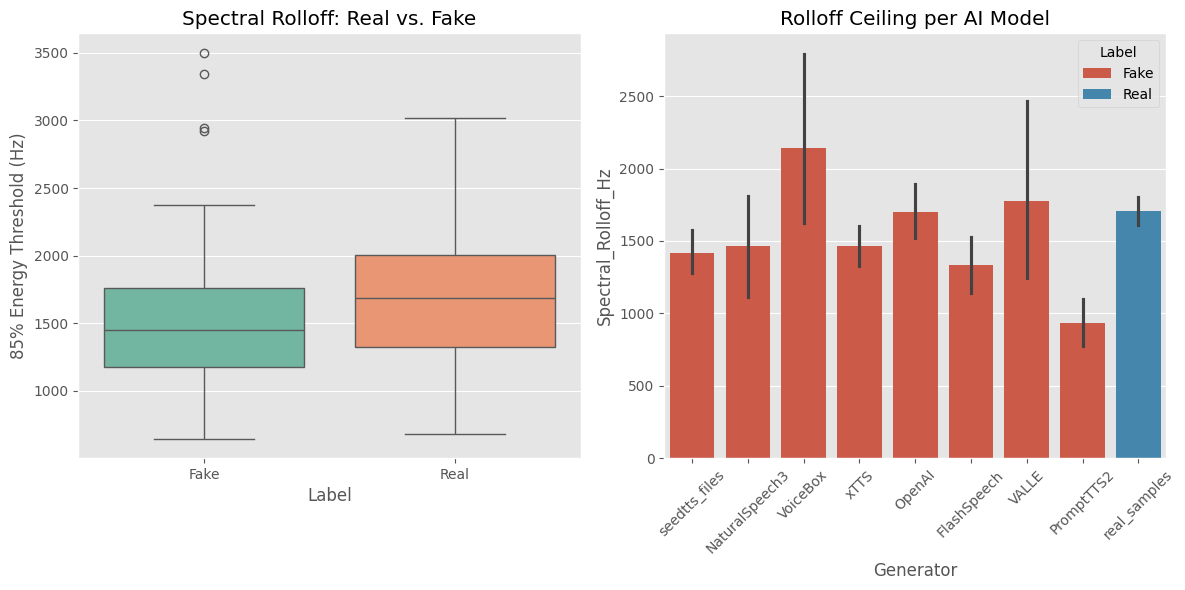

In [36]:
plt.figure(figsize=(12, 6))

# Plot 1: Distribution by Label
plt.subplot(1, 2, 1)
sns.boxplot(data=rolloff_df, x='Label', y='Spectral_Rolloff_Hz', palette='Set2')
plt.title("Spectral Rolloff: Real vs. Fake")
plt.ylabel("85% Energy Threshold (Hz)")

# Plot 2: Detailed by Generator
plt.subplot(1, 2, 2)
sns.barplot(data=rolloff_df, x='Generator', y='Spectral_Rolloff_Hz', hue='Label')
plt.xticks(rotation=45)
plt.title("Rolloff Ceiling per AI Model")

plt.tight_layout()
plt.show()

In [37]:
import torch
import torchaudio
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def extract_micro_variations(df, n_samples=50):
    subset = df.groupby('Label').sample(n=min(n_samples, len(df)//2))
    results = []

    for _, row in subset.iterrows():
        try:
            waveform, sr = torchaudio.load(row['file_path'])
            # Standardize for comparison
            if sr != 16000:
                waveform = torchaudio.transforms.Resample(sr, 16000)(waveform)

            # Convert to 1D
            data = waveform.flatten()

            # 1. Calculate SHIMMER (Amplitude Variation)
            # We look at the difference in peak heights across the clip
            peaks = torch.abs(data[1:-1])
            # Find local maxima (very simplified proxy)
            peak_indices = (data[1:-1] > data[:-2]) & (data[1:-1] > data[2:])
            actual_peaks = data[1:-1][peak_indices].abs()

            # Shimmer = Average difference between adjacent peak amplitudes
            shimmer = torch.mean(torch.abs(actual_peaks[1:] - actual_peaks[:-1]))

            # 2. Calculate JITTER (Frequency/Period Variation)
            # Find the distance (in samples) between zero-crossings
            zero_crossings = torch.where(torch.sign(data[1:]) != torch.sign(data[:-1]))[0]
            periods = zero_crossings[1:] - zero_crossings[:-1]

            # Jitter = Average variation in the length of these periods
            jitter = torch.mean(torch.abs(periods[1:].float() - periods[:-1].float()))

            results.append({
                'Label': row['Label'],
                'Generator': row['Generator'],
                'Jitter_Proxy': jitter.item(),
                'Shimmer_Proxy': shimmer.item()
            })
        except Exception:
            continue

    return pd.DataFrame(results)

# --- Execute ---
micro_df = extract_micro_variations(df)

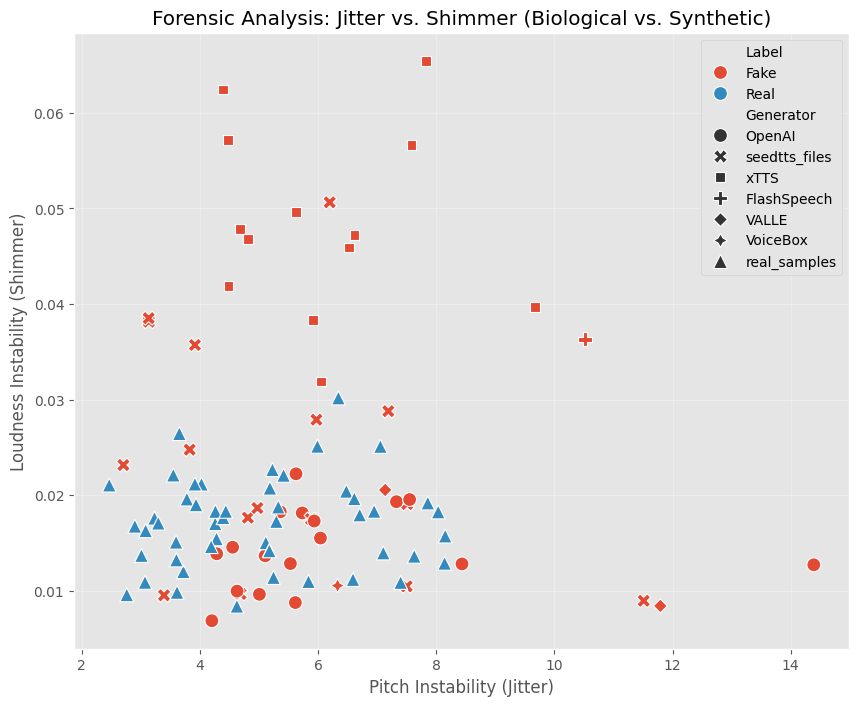

In [38]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=micro_df, x='Jitter_Proxy', y='Shimmer_Proxy', hue='Label', style='Generator', s=100)
plt.title("Forensic Analysis: Jitter vs. Shimmer (Biological vs. Synthetic)")
plt.xlabel("Pitch Instability (Jitter)")
plt.ylabel("Loudness Instability (Shimmer)")
plt.grid(True, alpha=0.3)
plt.show()

In [39]:
import torch
import torchaudio
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def extract_hnr_stats(df, n_samples=50):
    subset = df.groupby('Label').sample(n=min(n_samples, len(df)//2))
    results = []

    for _, row in subset.iterrows():
        try:
            waveform, sr = torchaudio.load(row['file_path'])
            if sr != 16000:
                waveform = torchaudio.transforms.Resample(sr, 16000)(waveform)

            # Use a 30ms window to find the 'voice' periodicity
            window_size = int(0.03 * 16000)
            wave_segment = waveform[0, :window_size]

            # 1. Calculate Autocorrelation (ACF)
            # This finds how much the signal repeats itself
            acf = torch.conv1d(wave_segment.unsqueeze(0).unsqueeze(0),
                               wave_segment.unsqueeze(0).unsqueeze(0))

            # 2. HNR Formula (Simplified Proxy)
            # Max ACF (Harmonics) divided by the 'Noise' (Total energy - Max ACF)
            max_acf = torch.max(acf)
            total_energy = torch.sum(wave_segment**2)

            # HNR in Decibels (dB)
            hnr = 10 * torch.log10(max_acf / (total_energy - max_acf + 1e-8))

            results.append({
                'Label': row['Label'],
                'Generator': row['Generator'],
                'HNR_dB': hnr.item()
            })
        except Exception:
            continue

    return pd.DataFrame(results)

# --- Execute ---
hnr_df = extract_hnr_stats(df)

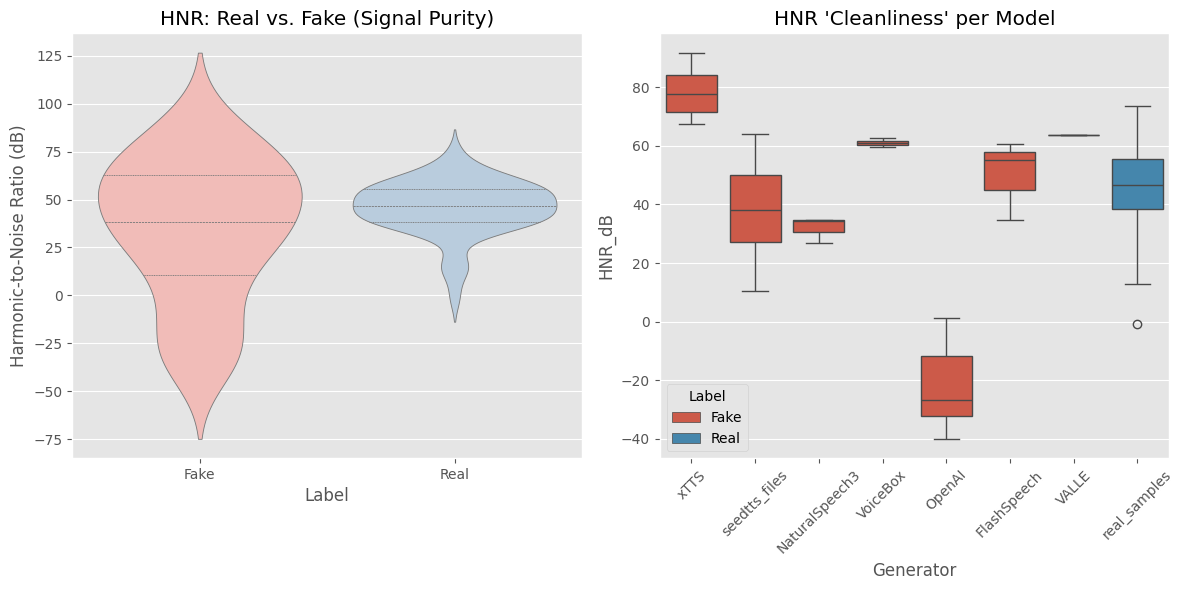

In [40]:
plt.figure(figsize=(12, 6))

# Plot 1: The Gap
plt.subplot(1, 2, 1)
sns.violinplot(data=hnr_df, x='Label', y='HNR_dB', inner="quart", palette="Pastel1")
plt.title("HNR: Real vs. Fake (Signal Purity)")
plt.ylabel("Harmonic-to-Noise Ratio (dB)")

# Plot 2: Per Generator Accuracy
plt.subplot(1, 2, 2)
sns.boxplot(data=hnr_df, x='Generator', y='HNR_dB', hue='Label')
plt.xticks(rotation=45)
plt.title("HNR 'Cleanliness' per Model")

plt.tight_layout()
plt.show()

In [41]:
import torch
import torchaudio
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def extract_rms_stats(df, n_samples=100):
    # Sample equally from Real and Fake
    subset = df.groupby('Label').sample(n=min(n_samples, len(df)//2))
    results = []

    for _, row in subset.iterrows():
        try:
            waveform, sr = torchaudio.load(row['file_path'])

            # 1. Standardize Volume (Peak Normalization)
            # This is crucial so we compare the "energy pattern," not just who was recorded louder.
            waveform = waveform / (waveform.abs().max() + 1e-8)

            # 2. Calculate RMS Energy
            # We square the values, take the mean, and then the square root
            # Using a window-based approach (standard for audio features)
            rms = torch.sqrt(torch.mean(waveform**2, dim=1))

            # 3. Calculate "Energy Volatility" (Standard Deviation)
            # This shows how much the volume "jumps" (Human-like) vs stays "flat" (AI-like)
            # We'll split the waveform into 100ms chunks to see this movement
            chunks = waveform.unfold(1, 1600, 1600) # 1600 samples = 100ms at 16kHz
            rms_chunks = torch.sqrt(torch.mean(chunks**2, dim=2))
            energy_variance = torch.std(rms_chunks)

            results.append({
                'Label': row['Label'],
                'Generator': row['Generator'],
                'Avg_RMS': rms.item(),
                'Energy_Volatility': energy_variance.item()
            })
        except Exception:
            continue

    return pd.DataFrame(results)

# --- Execute ---
rms_df = extract_rms_stats(df)

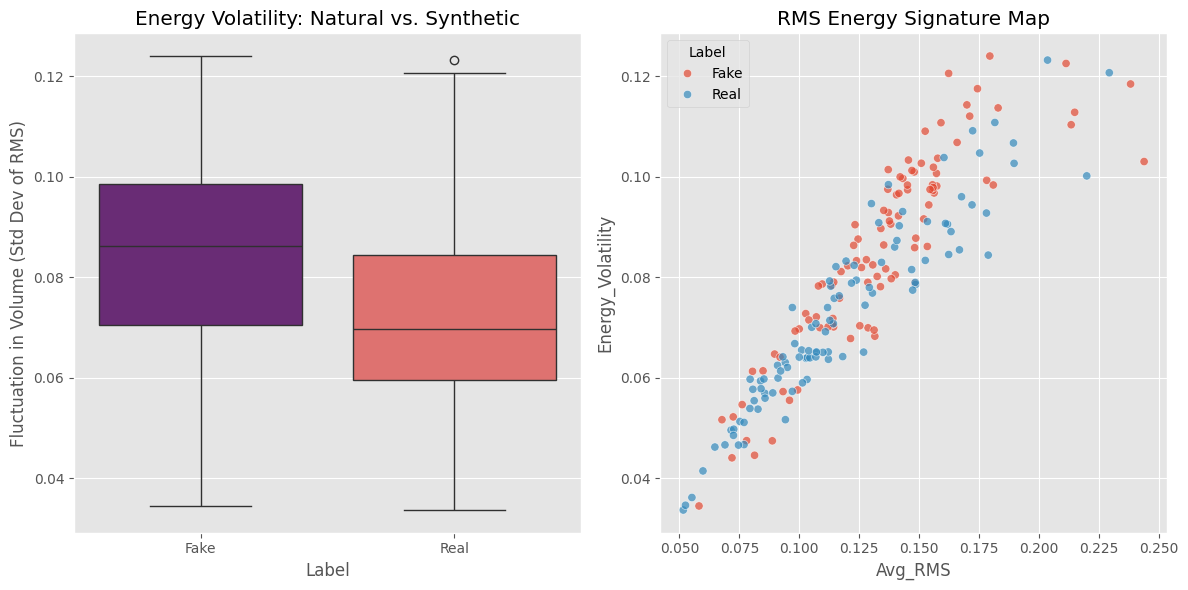

In [42]:
plt.figure(figsize=(12, 6))

# Plot 1: Energy Volatility (The "Breath" Test)
plt.subplot(1, 2, 1)
sns.boxplot(data=rms_df, x='Label', y='Energy_Volatility', palette='magma')
plt.title("Energy Volatility: Natural vs. Synthetic")
plt.ylabel("Fluctuation in Volume (Std Dev of RMS)")

# Plot 2: Relationship Mapping
plt.subplot(1, 2, 2)
sns.scatterplot(data=rms_df, x='Avg_RMS', y='Energy_Volatility', hue='Label', alpha=0.7)
plt.title("RMS Energy Signature Map")

plt.tight_layout()
plt.show()